# NicheSphere × PILOT: CODEX tutorial

This tutorial demonstrates how to use **NicheSphere** to discover differentially co-localized cellular niches in **CODEX multiplexed imaging** data and how to combine the resulting niches with **[PILOT](https://github.com/CostaLab/PILOT)** to infer sample-level disease trajectories.

**Prerequisites:** This tutorial assumes you have cloned the NicheSphere github repo and downloaded the data as indicated in the main NicheSphere MI Visium tutorial [[Nichesphere_tutorial_MIvisium.ipynb](Nichesphere_tutorial_MIvisium.ipynb)]

Co-localization probabilities are computed directly from cell spatial coordinates using a radius-based overlap approach, without requiring deconvolution. The workflow proceeds in five stages:

1. **Co-localization** — compute cell type pair co-localization probabilities per sample from CODEX cell boundaries
2. **Differential co-localization** — identify cell type pairs that are significantly enriched or depleted across conditions (MPL vs Ctrl)
3. **Niche detection** — cluster cell types into niches using the differential co-localization network
4. **Niche mapping** — assign each cell to a niche and visualise niche distributions across tissue slices and conditions
5. **PILOT trajectory inference** — use PILOT optimal transport to infer a pseudotime trajectory from niche compositions and identify co-localization pairs that drive disease progression


## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import scipy
import scipy.spatial.distance
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import scanpy as sc
import warnings
from community_layout.layout_class import CommunityLayout
import pilotpy as pl
import nichesphere
warnings.filterwarnings("ignore")

## 2. Data

In this tutorial, we will work with CODEX data from spleens of fibrosis mouse models and healthy controls as described in [this paper](https://www.cell.com/cell-stem-cell/fulltext/S1934-5909(26)00272-9). We load a pre-processed CODEX AnnData object containing cell segmentation coordinates, cell type annotations (``clusters_named``), sample identifiers, and condition labels (MPL, ThPO and Ctrl). Spatial coordinates are stored in ``obsm['spatial']``.

In [2]:
adata = sc.read('../../data/CODEX/CODEX_mouse_spleen.h5ad')
adata.obs.head()


,cell_id,orig.ident,total_arcsinh_intensity_bgFilt,nFeature,condition,sample,run,total_arcsinh_intensity_bgFilt_SCT,nFeature_SCT,SCT_snn_res.0.2,seurat_clusters,SCT_snn_res.0.5,SCT_snn_res.0.4,SCT_snn_res.0.3,clusters_named,is_HSPC,F4.80_CXCL12_pos,F480_C3_pos,is_HSPC_RP
0,0_Ctrl_1,CODEX_fusion_run27-29,6.246882,14,Ctrl,run27_Ctrl_1,run27,10,8,0,8,6,8,2,Erythrocytes_and_progenitors,no,F4/80+,F4/80+,no
1,1_Ctrl_1,CODEX_fusion_run27-29,1.324538,4,Ctrl,run27_Ctrl_1,run27,5,3,2,2,3,2,1,Granulocytes_Monocytes,no,negative,negative,no
2,2_Ctrl_1,CODEX_fusion_run27-29,10.242537,15,Ctrl,run27_Ctrl_1,run27,12,8,5,5,8,5,5,B_cell_zone,no,negative,negative,no
3,3_Ctrl_1,CODEX_fusion_run27-29,24.829945,24,Ctrl,run27_Ctrl_1,run27,15,13,1,0,2,0,4,Central_artery,WP,negative,negative,no
4,4_Ctrl_1,CODEX_fusion_run27-29,17.493036,23,Ctrl,run27_Ctrl_1,run27,13,8,4,0,2,0,6,Vessels,WP,negative,C3+,no


In [3]:
adata

AnnData object with n_obs × n_vars = 3676910 × 35
    obs: 'cell_id', 'orig.ident', 'total_arcsinh_intensity_bgFilt', 'nFeature', 'condition', 'sample', 'run', 'total_arcsinh_intensity_bgFilt_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'seurat_clusters', 'SCT_snn_res.0.5', 'SCT_snn_res.0.4', 'SCT_snn_res.0.3', 'clusters_named', 'is_HSPC', 'F4.80_CXCL12_pos', 'F480_C3_pos', 'is_HSPC_RP'
    uns: 'clusters_named_colors', 'is_HSPC_RP_colors'
    obsm: 'spatial'

## 3. Co-localization

### 3.1 Compute co-localization probabilities

For each sample we compute cell type pair co-localization probabilities from CODEX spatial coordinates using ``nichesphere.coloc.compute_sc_spatial_radius_coloc_matrix``. Two cells are considered co-localized if they fall within a ``radius`` of 100 pixels of each other. The resulting per-sample matrices are concatenated into a single long-format DataFrame.

Alternatively, one can also use the kNN based approach implemented in ``nichesphere.coloc.compute_sc_spatial_knn_coloc_matrix``.

In [ ]:
CTcolocalizationP = pd.DataFrame()

for smpl in list(adata.obs['sample'].unique()):
    print(smpl)
    anndata = adata[adata.obs['sample'] == smpl].copy()
    colocHM = nichesphere.coloc.compute_sc_spatial_radius_coloc_matrix(
        anndata, cluster_col='clusters_named', radius=100
    )
    colocHM['sample'] = smpl
    CTcolocalizationP = pd.concat([CTcolocalizationP, colocHM])

CTcolocalizationP.head()


### 3.2 Cell types and same-cell-type pairs

We extract the list of cell types and build a list of same-cell-type interaction pairs (e.g. ``Macrophages-Macrophages``). These will be excluded from downstream analysis because self-interactions are not informative for niche detection.


In [5]:
cell_types = CTcolocalizationP.columns[:-1]  # exclude the 'sample' column
oneCTints  = cell_types + '-' + cell_types   # same-cell-type pairs

print(f"{len(cell_types)} cell types, {len(oneCTints)} same-type pairs")
cell_types


13 cell types, 13 same-type pairs


Index(['B_cell_zone', 'Central_artery', 'DCs', 'Erythrocytes_and_progenitors',
       'Granulocytes_Monocytes', 'HSPC', 'Macrophages', 'Marginal_zone_region',
       'Mesothelium', 'Red_pulp_RCs', 'Sinusoids', 'T_cell_zone', 'Vessels'],
      dtype='object')

### 3.3 Reshape into a samples × cell type pairs matrix

``nichesphere.coloc.reshapeColoc`` pivots the long-format table into a matrix of samples × cell type pairs. Setting `complete=1` indicates that both directions of each pair (ct1–ct2 and ct2–ct1) are present in the data. The sum of all pair probabilities in each sample should equal 1.


In [6]:
colocPerSample = nichesphere.coloc.reshapeColoc(CTcoloc=CTcolocalizationP, complete=1)
print("Row sums (should all be ~1.0):")
colocPerSample.sum(axis=1)


Row sums (should all be ~1.0):


run27_Ctrl_1    1.0
run27_Ctrl_3    1.0
run27_MPL_2     1.0
run28_Ctrl_2    1.0
run28_Ctrl_5    1.0
run28_MPL_1     1.0
run28_ThPO_3    1.0
run28_ThPO_4    1.0
run29_MPL_2     1.0
run29_ThPO_4    1.0
run29_ThPO_5    1.0
dtype: float64

In [7]:
colocPerSample.head()

,B_cell_zone-B_cell_zone,B_cell_zone-Central_artery,B_cell_zone-DCs,B_cell_zone-Erythrocytes_and_progenitors,B_cell_zone-Granulocytes_Monocytes,B_cell_zone-HSPC,B_cell_zone-Macrophages,B_cell_zone-Marginal_zone_region,B_cell_zone-Mesothelium,B_cell_zone-Red_pulp_RCs,...,Vessels-Erythrocytes_and_progenitors,Vessels-Granulocytes_Monocytes,Vessels-HSPC,Vessels-Macrophages,Vessels-Marginal_zone_region,Vessels-Mesothelium,Vessels-Red_pulp_RCs,Vessels-Sinusoids,Vessels-T_cell_zone,Vessels-Vessels
run27_Ctrl_1,0.102136,0.006869,0.000009,0.005055,0.004469,0.000473,0.000558,0.019046,1.742594e-06,0.000513,...,0.005041,0.009573,0.000135,0.000365,0.005068,0.000100,0.000624,0.002337,0.004152,0.007139
run27_Ctrl_3,0.119352,0.008819,0.000048,0.003349,0.004645,0.001202,0.001826,0.021858,3.213629e-06,0.000409,...,0.007875,0.006789,0.000429,0.001206,0.009321,0.000334,0.000462,0.003408,0.008650,0.010218
run27_MPL_2,0.006515,0.006247,0.000017,0.007514,0.003183,0.000440,0.001912,0.004262,4.169636e-07,0.001074,...,0.021691,0.017076,0.001098,0.001804,0.011972,0.000004,0.002634,0.005725,0.002341,0.022955
run28_Ctrl_2,0.171681,0.009253,0.000033,0.002860,0.003065,0.001607,0.000911,0.021001,4.938815e-06,0.000315,...,0.003653,0.003575,0.000427,0.000417,0.006133,0.000054,0.000353,0.002182,0.009873,0.007196
run28_Ctrl_5,0.103740,0.008866,0.000086,0.007546,0.004908,0.001179,0.002820,0.028272,1.072352e-06,0.001356,...,0.009280,0.005276,0.000634,0.001462,0.011260,0.000160,0.000607,0.003482,0.007406,0.008770


### 3.4 Sample condition metadata

We build a sample × condition DataFrame from the AnnData ``obs``, which will be used to subset samples for differential testing and for PILOT.


In [8]:
sampleTypesDF = adata.obs[['sample', 'condition']].drop_duplicates()
sampleTypesDF.reset_index(drop=True, inplace=True)
sampleTypesDF.columns = ['sample', 'sampleType']
sampleTypesDF.index = sampleTypesDF['sample']
sampleTypesDF = sampleTypesDF.loc[colocPerSample.index]
sampleTypesDF


,sample,sampleType
run27_Ctrl_1,run27_Ctrl_1,Ctrl
run27_Ctrl_3,run27_Ctrl_3,Ctrl
run27_MPL_2,run27_MPL_2,MPL
run28_Ctrl_2,run28_Ctrl_2,Ctrl
run28_Ctrl_5,run28_Ctrl_5,Ctrl
run28_MPL_1,run28_MPL_1,MPL
run28_ThPO_3,run28_ThPO_3,ThPO
run28_ThPO_4,run28_ThPO_4,ThPO
run29_MPL_2,run29_MPL_2,MPL
run29_ThPO_4,run29_ThPO_4,ThPO


## 4. Differential co-localization analysis

### 4.1 Wilcoxon rank-sum test

We test for differential co-localization between MPL and Ctrl conditions using a Wilcoxon rank-sum test for each cell type pair. The resulting statistics and p-values are collected into a DataFrame.


In [9]:
pvals = [
    scipy.stats.ranksums(
        colocPerSample.loc[colocPerSample.index[sampleTypesDF.sampleType == 'MPL'], c],
        colocPerSample.loc[colocPerSample.index[sampleTypesDF.sampleType == 'Ctrl'], c]
    ).pvalue
    for c in colocPerSample.columns
]
stat = [
    scipy.stats.ranksums(
        colocPerSample.loc[colocPerSample.index[sampleTypesDF.sampleType == 'MPL'], c],
        colocPerSample.loc[colocPerSample.index[sampleTypesDF.sampleType == 'Ctrl'], c]
    ).statistic
    for c in colocPerSample.columns
]

DF = pd.DataFrame({'statistic': stat, 'p-value': pvals}, index=colocPerSample.columns)
DF.head()


,statistic,p-value
B_cell_zone-B_cell_zone,-2.121320,0.033895
B_cell_zone-Central_artery,-2.121320,0.033895
B_cell_zone-DCs,-1.060660,0.288844
B_cell_zone-Erythrocytes_and_progenitors,1.414214,0.157299
B_cell_zone-Granulocytes_Monocytes,-1.767767,0.077100


### 4.2 Differential co-localization score heatmap

We filter the test results at p < 0.1 and visualise the significant pairs in a clustered heatmap. Positive scores indicate enriched co-localization in MPL; negative scores indicate enrichment in Ctrl.


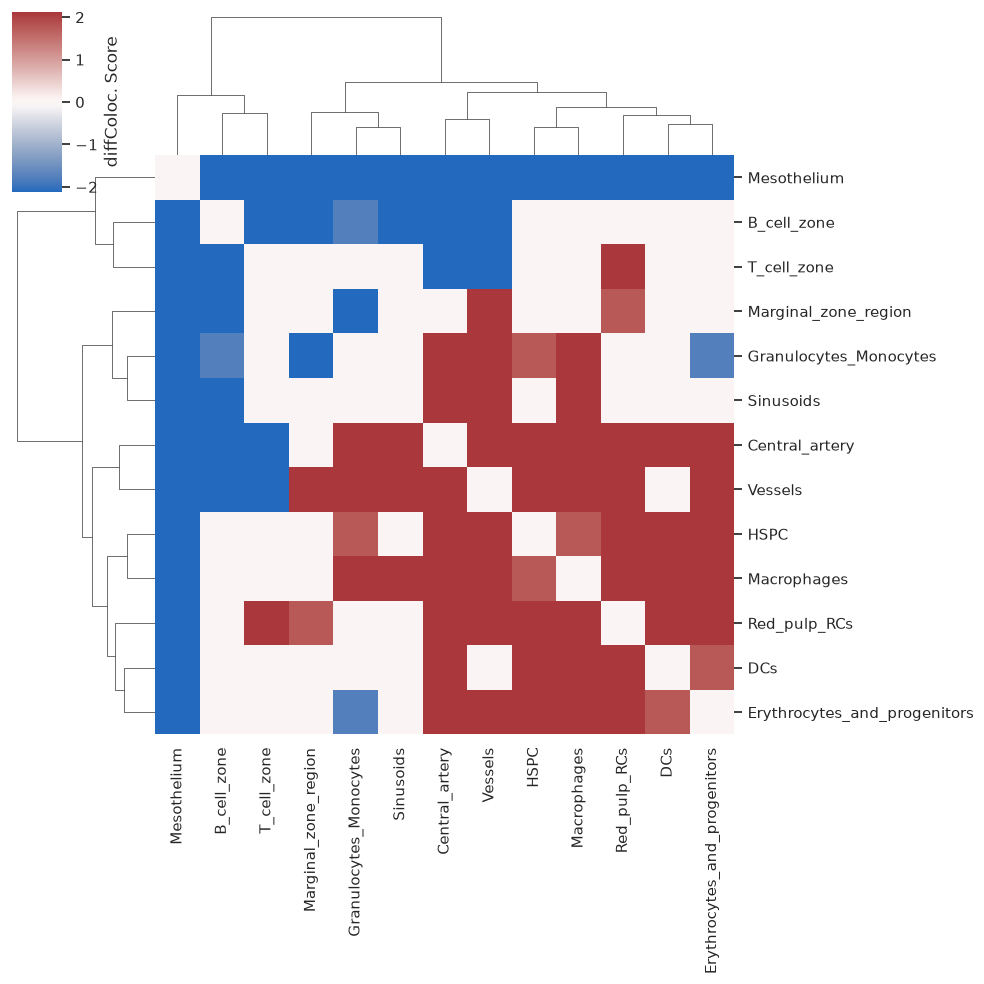

In [10]:
HM = nichesphere.tl.pval_filtered_HMdf(
    testDF=DF, oneCTinteractions=oneCTints, p=0.1, cell_types=cell_types
)

sns.set(font_scale=1)
plot = sns.clustermap(
    HM, cmap='vlag', center=0, method='ward',
    cbar_kws={'label': 'diffColoc. Score'}
)
#plot.savefig('./figures/diffcoloc_MPL_Ctrl_rev.pdf')


## 5. Differential co-localization network

### 5.1 Adjacency matrix

To build the network, we compute a similarity matrix from the euclidean distances between cell type differential co-localization score profiles. Cell type pairs with no significant differential co-localization (score = 0) receive a similarity of 0.


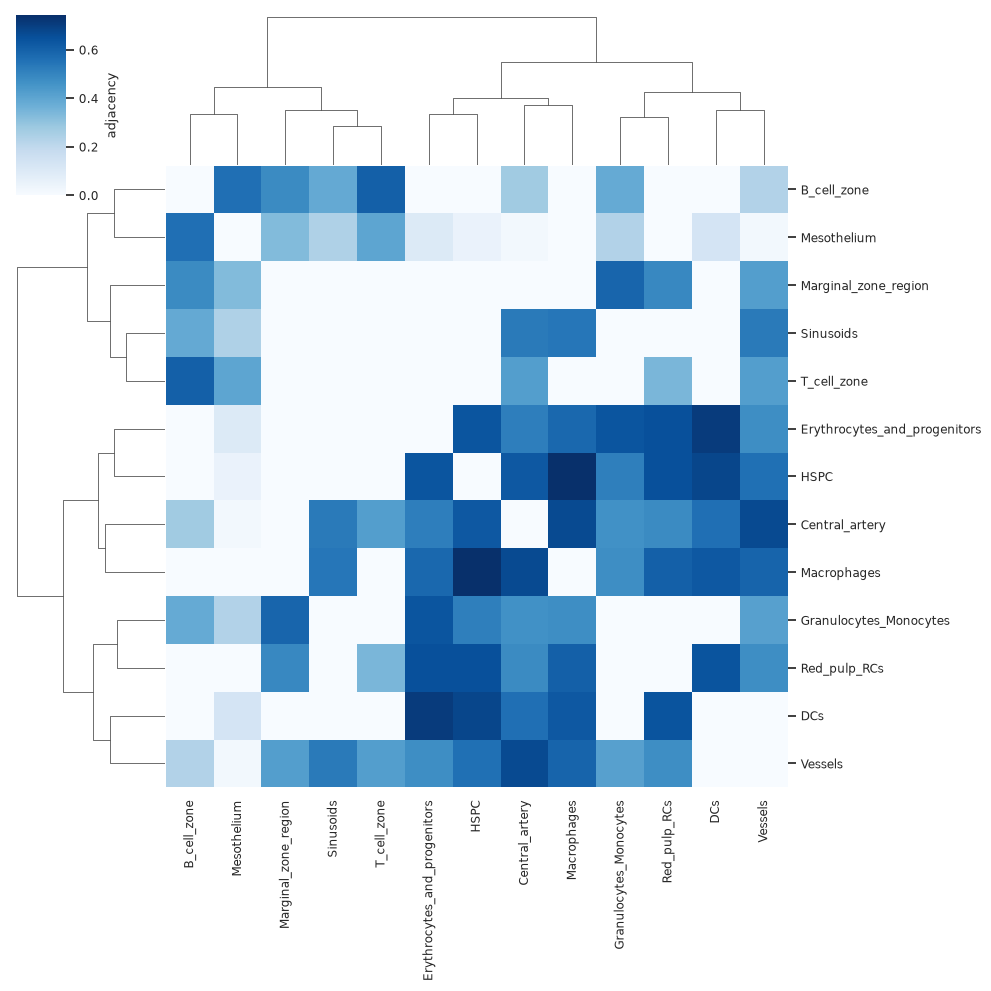

In [11]:
HMdist = pd.DataFrame(
    scipy.spatial.distance.squareform(scipy.spatial.distance.pdist(HM)),
    columns=HM.columns, index=HM.index
)
HMsimm = 1 - HMdist / HMdist.max().max()
HMsimm[HM == 0] = 0  # zero out non-significant pairs

sns.set(font_scale=0.8)
plot = sns.clustermap(HMsimm, cmap='Blues', method='ward', cbar_kws={'label': 'adjacency'})


### 5.2 Network visualisation (initial layout)

We first plot the network with a spring layout to get an overview of the structure before running community detection. All cell types are assigned to a single preliminary group at this stage.


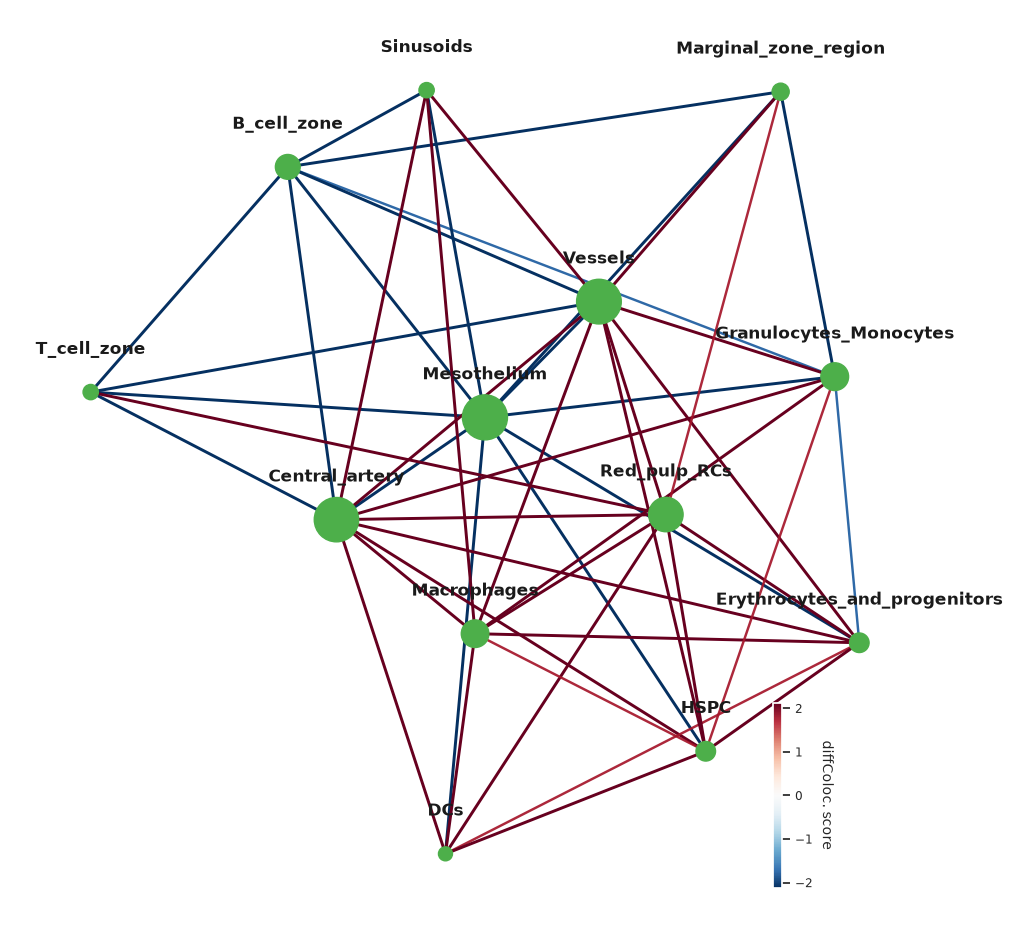

In [12]:
niches_dict_init = {'1_': list(HM.index)}
clist_init = ['#4daf4a']

plt.rcParams['axes.facecolor'] = "None"
gCol = nichesphere.coloc.colocNW(
    x_diff=HM, adj=HMsimm,
    cell_group=niches_dict_init, clist=clist_init,
    nodeSize='betweeness', thr=1, fsize=(12, 12)
)


## 6. Niche detection

### 6.1 Community detection with Louvain

We use the unsigned similarity network and Louvain community detection (via ``CommunityLayout``) to partition cell types into niches. The ``resolution`` parameter controls niche granularity — increase it to obtain more, smaller niches.


In [13]:
gCol_unsigned = nx.from_pandas_adjacency(HMsimm, create_using=nx.Graph)

cl = CommunityLayout(
    gCol_unsigned,
    community_compression=0.3,
    layout_algorithm=nx.spring_layout,
    layout_kwargs={"k": 75, "iterations": 1000},
    community_algorithm=nx.algorithms.community.louvain_communities,
    community_kwargs={"resolution": 1.5, 'seed': 12, 'weight': 'weight'}
)

d = {index: list(value) for index, value in enumerate(cl.communities())}
print(pd.DataFrame.from_dict(d, orient='index').T.to_string(index=False))


Building meta-graph
Metagraph is a Graph with 4 nodes and 6 edges


100%|██████████| 4/4 [00:00<00:00, 135.50it/s]


          0                            1                      2              3
B_cell_zone                          DCs   Marginal_zone_region Central_artery
Mesothelium                 Red_pulp_RCs Granulocytes_Monocytes      Sinusoids
T_cell_zone                         HSPC                Vessels    Macrophages
       None Erythrocytes_and_progenitors                   None           None


### 6.2 Name niches and assign colors

We assign names to each detected community and pick a color palette for visualization.


In [14]:
niche_names = ['n1', 'n2', 'n3', 'n4']
niches_dict  = dict(zip(niche_names, list(d.values())))
print(pd.DataFrame.from_dict(niches_dict, orient='index').T.to_string(index=False))


         n1                           n2                     n3             n4
B_cell_zone                          DCs   Marginal_zone_region Central_artery
Mesothelium                 Red_pulp_RCs Granulocytes_Monocytes      Sinusoids
T_cell_zone                         HSPC                Vessels    Macrophages
       None Erythrocytes_and_progenitors                   None           None


In [15]:
clist      = ['#95cf92', '#369acc', '#de324c', '#ffff33']
niche_cols = pd.Series(clist, index=list(niches_dict.keys()))
niches_df  = nichesphere.tl.cells_niche_colors(
    CTs=cell_types, niche_colors=niche_cols, niche_dict=niches_dict
)
niches_df.head()


,cell,niche,color
cell,,,
B_cell_zone,B_cell_zone,n1,#95cf92
Central_artery,Central_artery,n4,#ffff33
DCs,DCs,n2,#369acc
Erythrocytes_and_progenitors,Erythrocytes_and_progenitors,n2,#369acc
Granulocytes_Monocytes,Granulocytes_Monocytes,n3,#de324c


### 6.3 Community layout network plot

We use the community layout positions to draw the final network with cell types colored by niche. Node size reflects betweenness centrality.


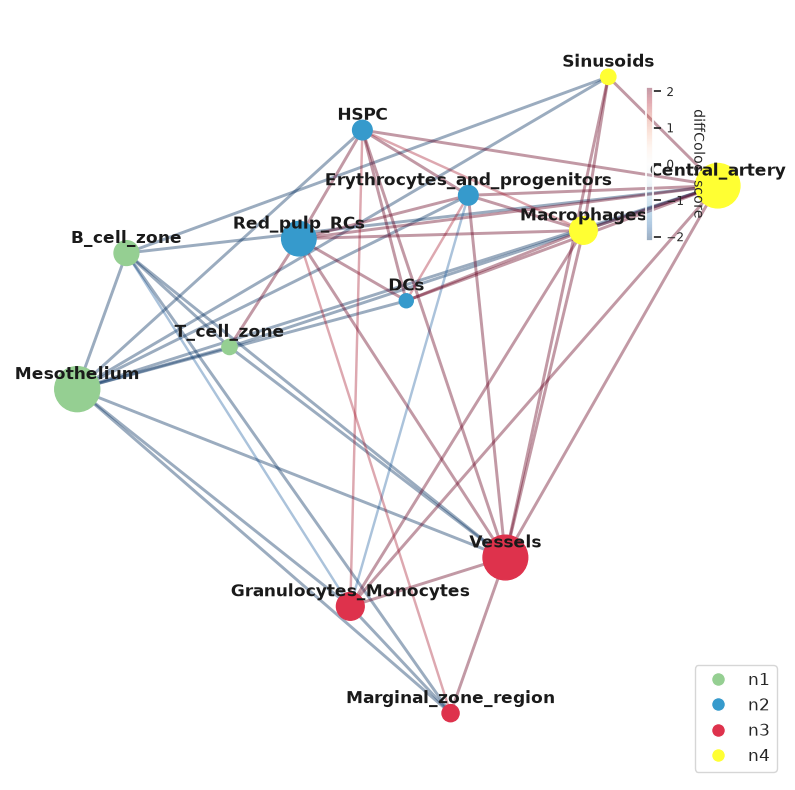

In [16]:
pos = cl.full_positions
# To reuse positions from a previous run instead:
# pos = np.load('diffcolocNW_MPL_Ctrl_rev_pos.npy', allow_pickle=True).item()

plt.rcParams['axes.facecolor'] = "None"
gCol = nichesphere.coloc.colocNW(
    x_diff=HM, adj=HMsimm,
    cell_group=niches_dict, clist=clist,
    nodeSize='betweeness', layout=None,
    lab_spacing=0.05, thr=1, alpha=0.4,
    fsize=(10, 10), pos=pos,
    edge_scale=1, legend_ax=[0.7, 0.7, 0.15, 0.2]
)
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=clist[i], lw=4,
               label=niche_names[i], ms=10)
    for i in range(len(niche_names))
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=12)
#plt.savefig('./figures/diffcolocNW_MPL_Ctrl_rev.pdf', bbox_inches='tight')


Save the positions to disk so the same layout can be reproduced in future runs.

In [17]:
# Save node positions for reproducibility
#np.save('diffcolocNW_MPL_Ctrl_rev_pos.npy', pos)


### 6.4 Assign graph properties for interactive visualisation

We assign node and niche properties to the network object and store them as node attributes, enabling features like node size-encoding in the interactive ``gravis`` viewer.


In [18]:
nichesphere.tl.assign_properties(
    gCol,
    communities=cl.communities(),
    colors=clist,
    pos=pos,
    simmilarity_weights=True,
    node_coord_sf=100,
    g_unsigned=gCol_unsigned
)

import gravis as gv
gv.d3(gCol, edge_size_data_source='weight_abs', zoom_factor=0.35, layout_algorithm_active=False)


## 7. Network statistics

### 7.1 Node centrality

We compute betweenness centrality, degree, PageRank, and signed (positive/negative) degree centrality for each cell type (node).


In [19]:
nw_stats = nichesphere.tl.compute_network_stats(gCol)
nw_stats.head()


,betweenness,pagerank,degree_positive,degree_negative
B_cell_zone,-29.719207,-3.557735,0.000000,0.583333
Central_artery,28.961483,0.775290,0.666667,0.250000
DCs,0.000000,1.233241,0.416667,0.083333
Erythrocytes_and_progenitors,24.852959,0.864063,0.500000,0.166667
Granulocytes_Monocytes,-27.174887,-0.483078,0.333333,0.333333


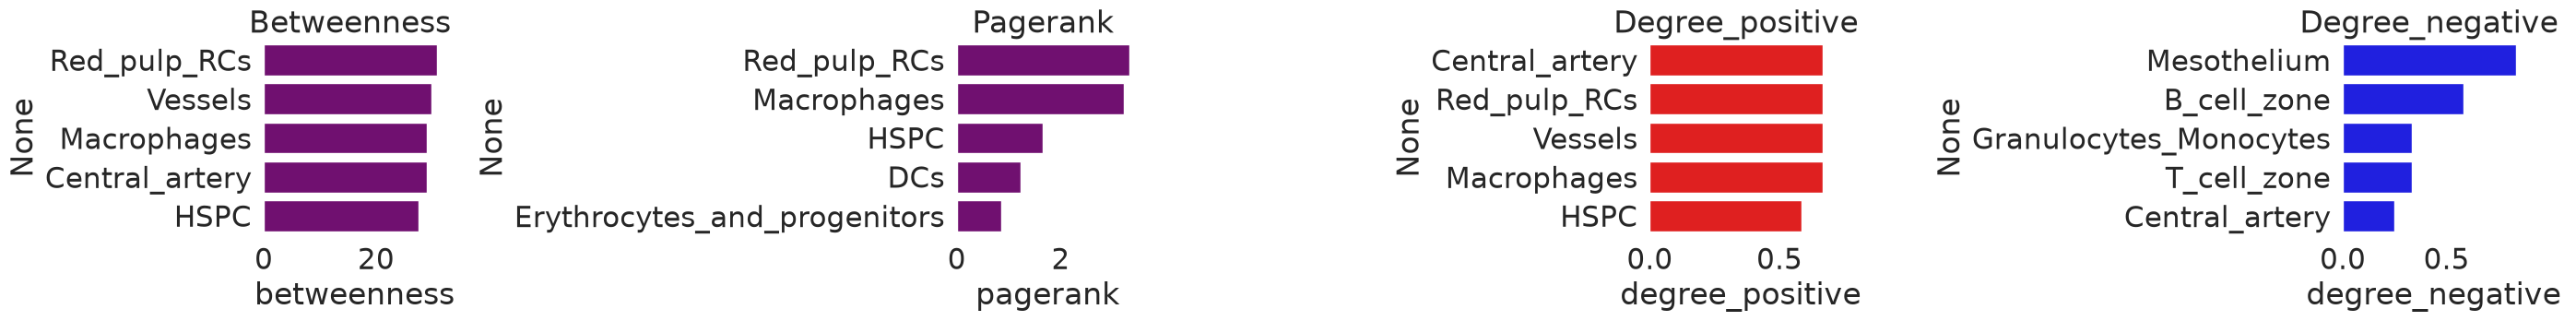

In [20]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = 'None'
f=nichesphere.tl.plot_top_stats(nw_stats, top_n=5)
#f.savefig('./figures/diffcolocNW_MPL_Ctrl_stats_top5.pdf', bbox_inches='tight')


### 7.2 Niche cohesion: internal vs external edge weights

We compare the distribution of co-localization scores for edges connecting cell types *within* the same niche (internal) against edges connecting cell types *across* niches (external). A niche with predominantly positive internal edges is more tightly co-localized than expected.


In [21]:
vc_map_named = {node: niche for niche, members in niches_dict.items() for node in members}

edge_stats = nichesphere.niche_stats.community_edge_stats_df(gCol, vc_map_named)
edge_stats


,internal_pos_count,internal_pos_weight,internal_neg_count,internal_neg_weight,external_pos_count,external_pos_weight,external_neg_count,external_neg_weight
community,,,,,,,,
n1,0,0.000000,3,6.363961,1,2.121320,15,31.466252
n2,6,12.374369,0,0.000000,14,28.637825,4,8.131728
n3,2,4.242641,1,2.121320,10,20.506097,8,16.263456
n4,3,6.363961,0,0.000000,13,27.223611,5,10.606602


<Axes: title={'center': 'Internal vs external edge weight distributions by niche'}, xlabel='niche', ylabel='edge weight'>

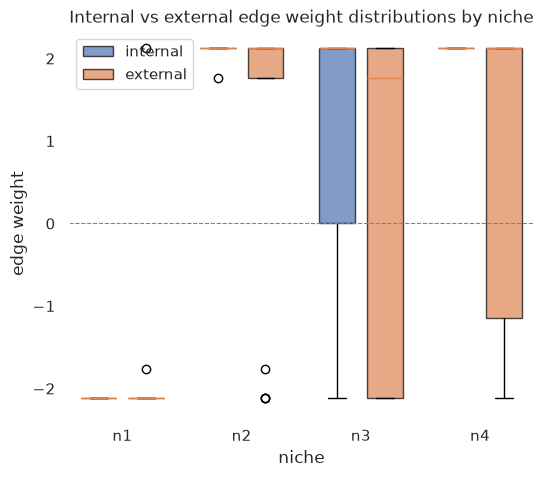

In [22]:
sns.set(font_scale=1)
plt.rcParams['axes.facecolor'] = 'None'
nichesphere.niche_stats.plot_internal_external_boxplots(gCol, vc_map_named)
#plt.savefig('./figures/diffcolocNW_MPL_Ctrl_int_ext_boxplots.pdf', bbox_inches='tight')


In [23]:
signed      = nichesphere.niche_stats.community_signed_weight_distributions(gCol, vc_map_named)
communities = list(signed.keys())

pairwise_stats = nichesphere.niche_stats.pairwise_ranksums_int_ext(
    data_int=[signed[c]['internal'] for c in communities],
    data_ext=[signed[c]['external'] for c in communities],
    communities=communities
)
pairwise_stats


,niche,statistic,p_value,p_value_corrected
0,n1,-0.335410,0.737316,0.737316
1,n2,0.933333,0.350648,0.731425
2,n3,0.402015,0.687673,0.737316
3,n4,0.904534,0.365712,0.731425


## 8. Niche mapping

To keep this section readable we define three small helper functions that each handle one self-contained mapping/plotting task. These are good candidates for a future `nichesphere.tl` addition.

In [24]:
def assign_niches_to_adata(adata, niches_df, niche_col='niche',
                            cell_type_col='clusters_named'):
    """Add a niche column to ``adata.obs`` based on a cell-type → niche mapping.

    Parameters
    ----------
    adata : AnnData
        Spatial AnnData (all samples).
    niches_df : pd.DataFrame
        Output of ``nichesphere.tl.cells_niche_colors``; must have columns
        ``'cell'`` (cell type name) and ``'niche'`` (niche label, Categorical).
    niche_col : str, default ``'niche'``
        Name of the new column added to ``adata.obs``.
    cell_type_col : str, default ``'clusters_named'``
        Column in ``adata.obs`` containing cell type labels.

    Returns
    -------
    adata : AnnData
        Input AnnData with ``obs[niche_col]`` added in-place.
    """
    adata.obs[niche_col] = 'unassigned'
    ct_to_niche = dict(zip(niches_df['cell'], niches_df['niche']))
    adata.obs[niche_col] = adata.obs[cell_type_col].map(ct_to_niche).fillna('unassigned')
    adata.obs[niche_col] = (
        adata.obs[niche_col].astype('category')
                            .cat.reorder_categories(niches_df['niche'].cat.categories)
    )
    return adata


def plot_niche_spatial_grid(adata, niche_col, condition_col, sample_col,
                             condition_order, spot_size=20, ncols=5,
                             figsize_per_cell=(5, 5), save_path=None):
    """Grid of spatial niche maps, one row per condition, one column per sample.

    Parameters
    ----------
    adata : AnnData
        Spatial AnnData with ``obsm['spatial']`` and niche labels in ``obs``.
    niche_col : str
        Column in ``adata.obs`` with niche labels.
    condition_col : str
        Column in ``adata.obs`` with condition labels.
    sample_col : str
        Column in ``adata.obs`` with sample identifiers.
    condition_order : list of str
        Conditions to plot, in the desired row order.
    spot_size : int, default 20
        Spot size passed to ``sc.pl.spatial``.
    ncols : int, default 5
        Maximum number of sample columns per row.
    figsize_per_cell : tuple, default (5, 5)
        (width, height) of each subplot panel.
    save_path : str or None, default None
        If provided, the figure is saved to this path.

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    nrows = len(condition_order)
    w, h  = figsize_per_cell
    fig, axes = plt.subplots(nrows, ncols, figsize=(w * ncols, h * nrows))
    plt.close(fig)

    for row_idx, cond in enumerate(condition_order):
        samples = list(adata.obs[sample_col][adata.obs[condition_col] == cond].unique())
        for col_idx in range(ncols):
            ax = axes[row_idx][col_idx]
            if col_idx < len(samples):
                ad = adata[adata.obs[sample_col] == samples[col_idx]].copy()
                sc.pl.spatial(
                    ad, color=[niche_col], spot_size=spot_size,
                    use_raw=False, title=samples[col_idx],
                    ax=ax, show=False
                )
            else:
                ax.axis('off')  # hide empty panels

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300)
    return fig


def plot_niche_proportions(adata, niche_col, condition_col,
                            condition_order, niche_colors,
                            save_path=None):
    """Stacked bar chart of normalised niche proportions per condition.

    Parameters
    ----------
    adata : AnnData
        AnnData with niche and condition labels in ``obs``.
    niche_col : str
        Column in ``adata.obs`` with niche labels.
    condition_col : str
        Column in ``adata.obs`` with condition labels.
    condition_order : list of str
        Order of conditions along the x-axis.
    niche_colors : pd.Series
        Series mapping niche names to hex color strings.
    save_path : str or None, default None
        If provided, the figure is saved to this path.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    counts = adata.obs.groupby([condition_col, niche_col]).size().unstack(fill_value=0)
    norm   = (counts.T / counts.T.sum()).T
    norm   = norm.reindex(condition_order)

    ax = norm.plot.bar(
        stacked=True,
        color=[niche_colors.get(n, '#cccccc') for n in norm.columns],
        figsize=(6, 5)
    )
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    ax.set_xlabel('')
    ax.set_ylabel('Proportion')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    return ax


### 8.1 Assign each cell to a niche

Each cell inherits the niche of its annotated cell type.


In [25]:
adata = assign_niches_to_adata(adata, niches_df, niche_col='MPL_Ctrl_niche')

cols = pd.Series(clist, index=niche_names)
adata.uns['MPL_Ctrl_niche_colors'] = list(cols[niches_df['niche'].cat.categories])

adata.obs[['clusters_named', 'MPL_Ctrl_niche']].head(10)


,clusters_named,MPL_Ctrl_niche
0,Erythrocytes_and_progenitors,n2
1,Granulocytes_Monocytes,n3
2,B_cell_zone,n1
3,Central_artery,n4
4,Vessels,n3
5,Marginal_zone_region,n3
6,Marginal_zone_region,n3
7,Marginal_zone_region,n3
8,Marginal_zone_region,n3
9,Central_artery,n4


In [26]:
# Optional: export niche assignments to CSV
#adata.obs.to_csv('CODEX_MPL_Ctrl_niches_rev.csv')


### 8.2 Spatial niche maps

One row per condition.

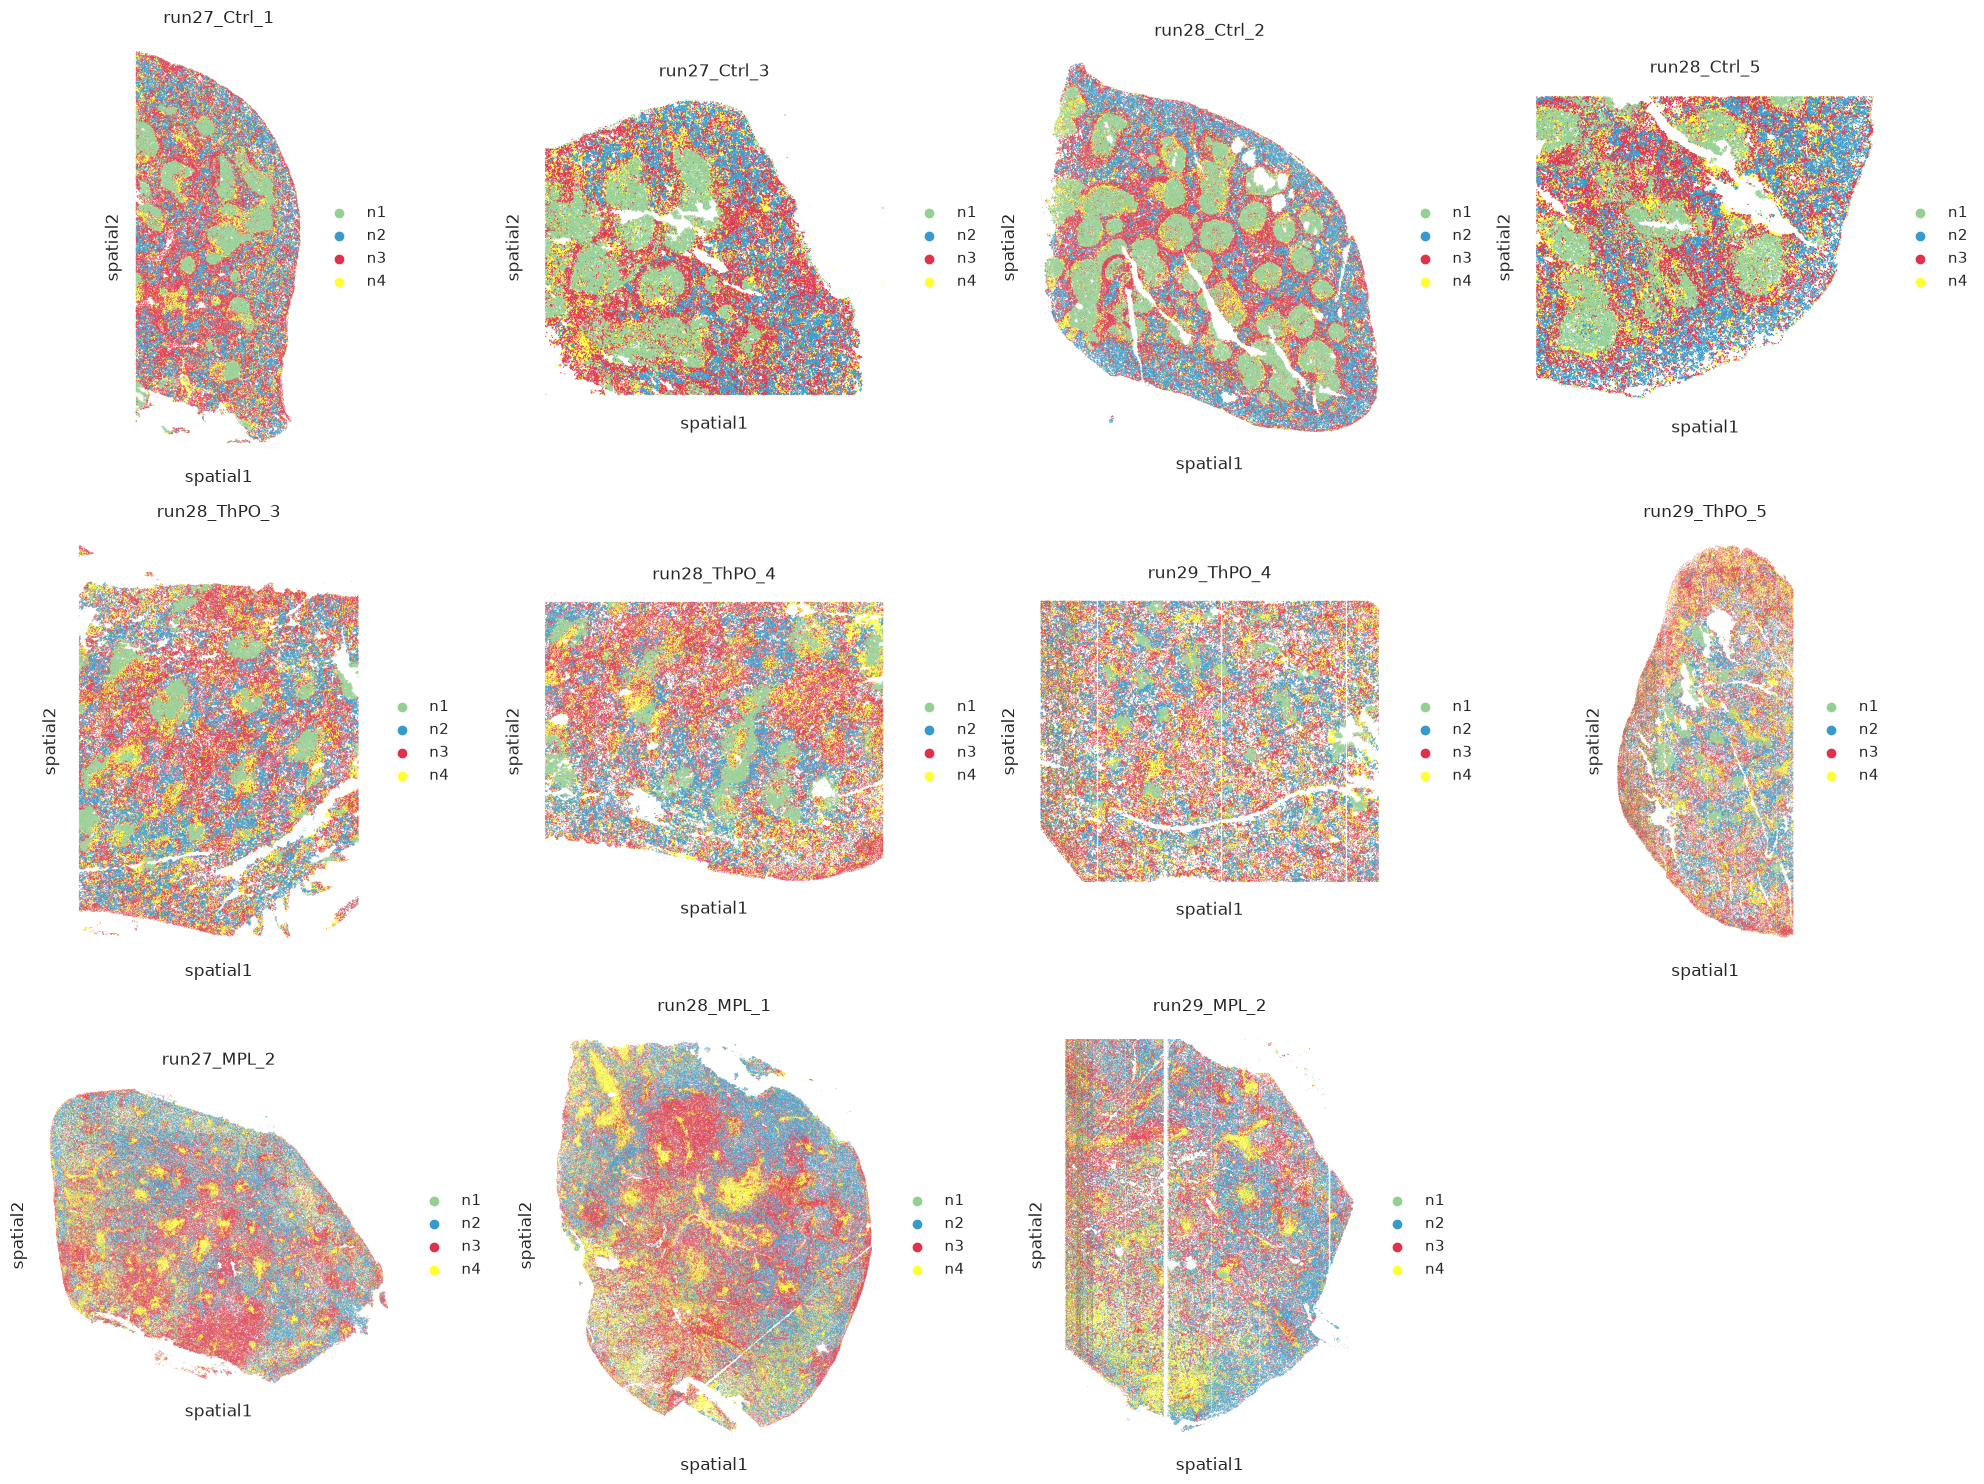

In [27]:
fig = plot_niche_spatial_grid(
    adata,
    niche_col='MPL_Ctrl_niche',
    condition_col='condition',
    sample_col='sample',
    condition_order=['Ctrl', 'ThPO', 'MPL'],
    spot_size=20,
    ncols=4,
    #save_path='./figures/MPL_Ctrl_niche_in_slices_rev.png'
)
fig


### 8.3 Niche proportions per condition

Stacked bar chart of normalised niche abundances across conditions.

<Axes: ylabel='Proportion'>

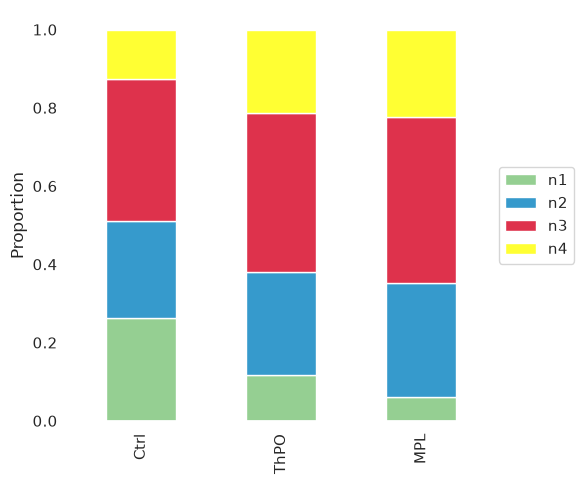

In [28]:
plot_niche_proportions(
    adata,
    niche_col='MPL_Ctrl_niche',
    condition_col='condition',
    condition_order=['Ctrl', 'ThPO', 'MPL'],
    niche_colors=cols,
    #save_path='./figures/MPL_Ctrl_niche_in_conditions_rev.pdf'
)


### 8.4 Co-localization boxplots for selected pairs

A quick sanity-check: inspect individual cell type pair co-localization probabilities across conditions.

In [29]:
pairs_of_interest = [
    'HSPC-Red_pulp_RCs', 'HSPC-Macrophages',
    'B_cell_zone-Marginal_zone_region', 'T_cell_zone-Marginal_zone_region'
]

bdf = colocPerSample[pairs_of_interest].copy()
bdf['status'] = sampleTypesDF['sampleType'].values
bdf['status'] = bdf['status'].astype('category').cat.reorder_categories(['Ctrl', 'ThPO', 'MPL'])

## color per condition
cond_colors=['#48b192', '#f9ce4e', '#e17f34']


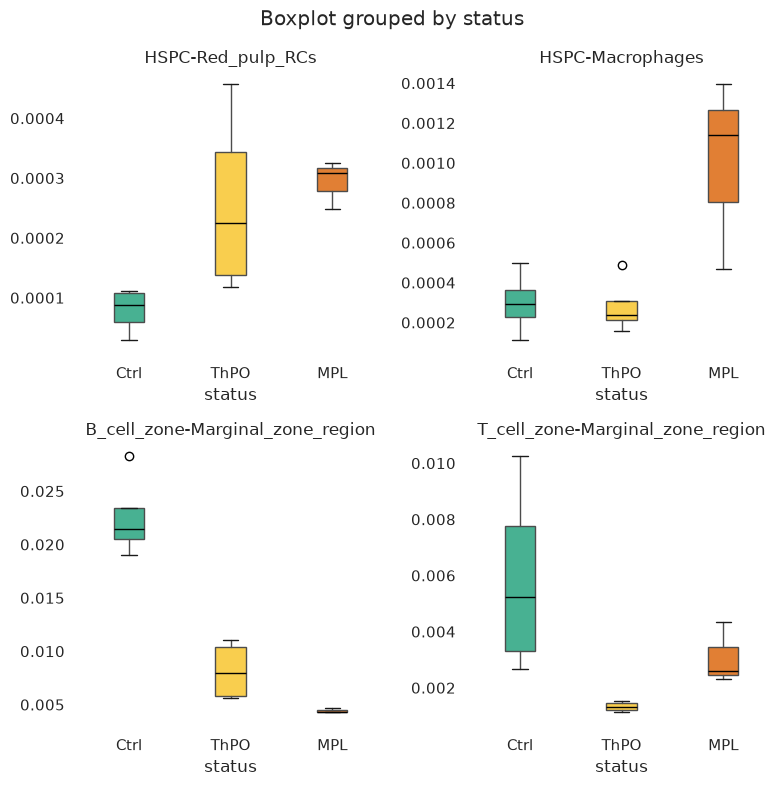

In [30]:
fig, axs = plt.subplots(2,2, figsize=(8, 8))
for i, ax in enumerate(axs.flatten()):
    bp_dict=bdf.boxplot(column=pairs_of_interest[i], by='status', 
                grid=False, patch_artist=True, return_type='both', ax=ax)
    out_dict=bp_dict[pairs_of_interest[i]].lines
    # Iterate through the boxes and apply colors
    for patch, color in zip(out_dict['boxes'], cond_colors):
        patch.set_facecolor(color)
    
    for median in out_dict['medians']:
        median.set_color('black')
    
    i=i+1
fig.tight_layout()
fig.show()

## 9. PILOT: niche-informed disease trajectory inference

We use **[PILOT](https://github.com/CostaLab/PILOT)** (PatIent Level distance with Optimal Transport) to compute sample-level disease trajectories from CODEX data, using NicheSphere niches as the grouping variable.

PILOT computes optimal transport distances between tissue samples based on their niche compositions and fits a diffusion map to reveal the trajectory of disease progression.

### 9.1 Prepare cell type proportions

PILOT requires a spot/cell-level AnnData with:
- ``obs['niche']`` — niche assignment per cell
- ``obs['patient_region_id']`` — sample identifier
- ``obs['status']`` — condition label
- ``obsm['CTprops']`` — cell type proportions per cell (used to compute niche-to-niche cost matrices)

We load the pre-computed PILOT pseudotime CSV (obtained from a previous PILOT run) and compute cell type proportions per sample.


In [31]:
# Cell type proportion per sample (used as PILOT embedding)
CTprops = adata.obs.groupby(['sample', 'clusters_named']).size().unstack(fill_value=0)
CTprops = CTprops.div(CTprops.sum(axis=1), axis=0)
CTprops.head()


clusters_named,B_cell_zone,Central_artery,DCs,Erythrocytes_and_progenitors,Granulocytes_Monocytes,HSPC,Macrophages,Marginal_zone_region,Mesothelium,Red_pulp_RCs,Sinusoids,T_cell_zone,Vessels
sample,,,,,,,,,,,,,
run27_Ctrl_1,0.144362,0.057967,0.000175,0.225962,0.236412,0.005113,0.011879,0.134293,0.001754,0.022772,0.067849,0.041462,0.050002
run27_Ctrl_3,0.191034,0.061671,0.000314,0.199753,0.142787,0.007789,0.017825,0.163382,0.004851,0.009189,0.059914,0.071435,0.070055
run27_MPL_2,0.037803,0.118916,0.000263,0.235231,0.223319,0.013841,0.026353,0.111725,0.000014,0.038429,0.063792,0.021878,0.108437
run28_Ctrl_2,0.224110,0.048207,0.000176,0.225653,0.123458,0.013923,0.009759,0.158535,0.001856,0.011962,0.051644,0.081490,0.049226
run28_Ctrl_5,0.186292,0.052486,0.000321,0.220214,0.092939,0.012167,0.021943,0.189164,0.003512,0.009616,0.060820,0.084632,0.065895


### 9.2 Wasserstein distances between samples

``pl.tl.wasserstein_distance`` computes optimal transport distances between samples using niche compositions (``clusters_col='niche'``) and cell type proportions as the ground cost matrix (``emb_matrix='CTprops'``).


In [32]:
sc.pp.pca(adata, n_comps=30)
adata.obsm['PCA'] = pd.DataFrame(
    adata.obsm['X_pca'], 
    index=adata.obs_names)

In [33]:
pl.tl.wasserstein_distance(
    adata,
    emb_matrix='PCA',
    clusters_col='MPL_Ctrl_niche',
    sample_col='sample',
    status='condition',
    use_centroids=False
)


### 9.3 Disease trajectory

A diffusion map on the Wasserstein distances reveals the trajectory of disease progression. Samples are colored by condition. The trajectory separates Ctrl, ThPO, and MPL samples along the pseudotime axis.


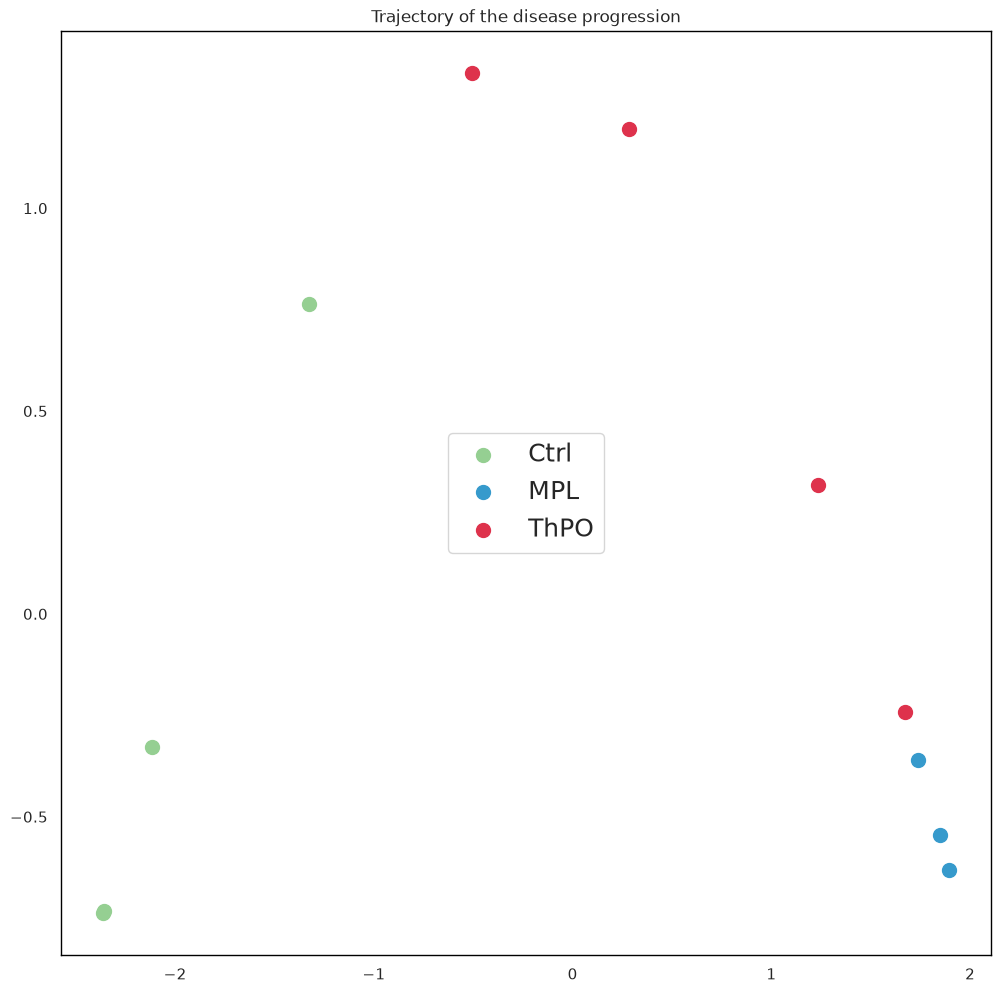

In [34]:
pl.pl.trajectory(
    adata,
    colors=clist,
    font_size=14,
    location_labels='center',
    fontsize_legend=18,
    knn=3
)
#plt.savefig('./figures/PILOT_trajectory_MPL_Ctrl.pdf', bbox_inches='tight')


### 9.4 Principal graph and pseudotime

PILOT fits a principal graph to the diffusion map embedding and assigns a pseudotime score to each sample. Set ``source_node`` to the index of the healthy/control end of the trajectory (inspect the trajectory plot above to identify it).


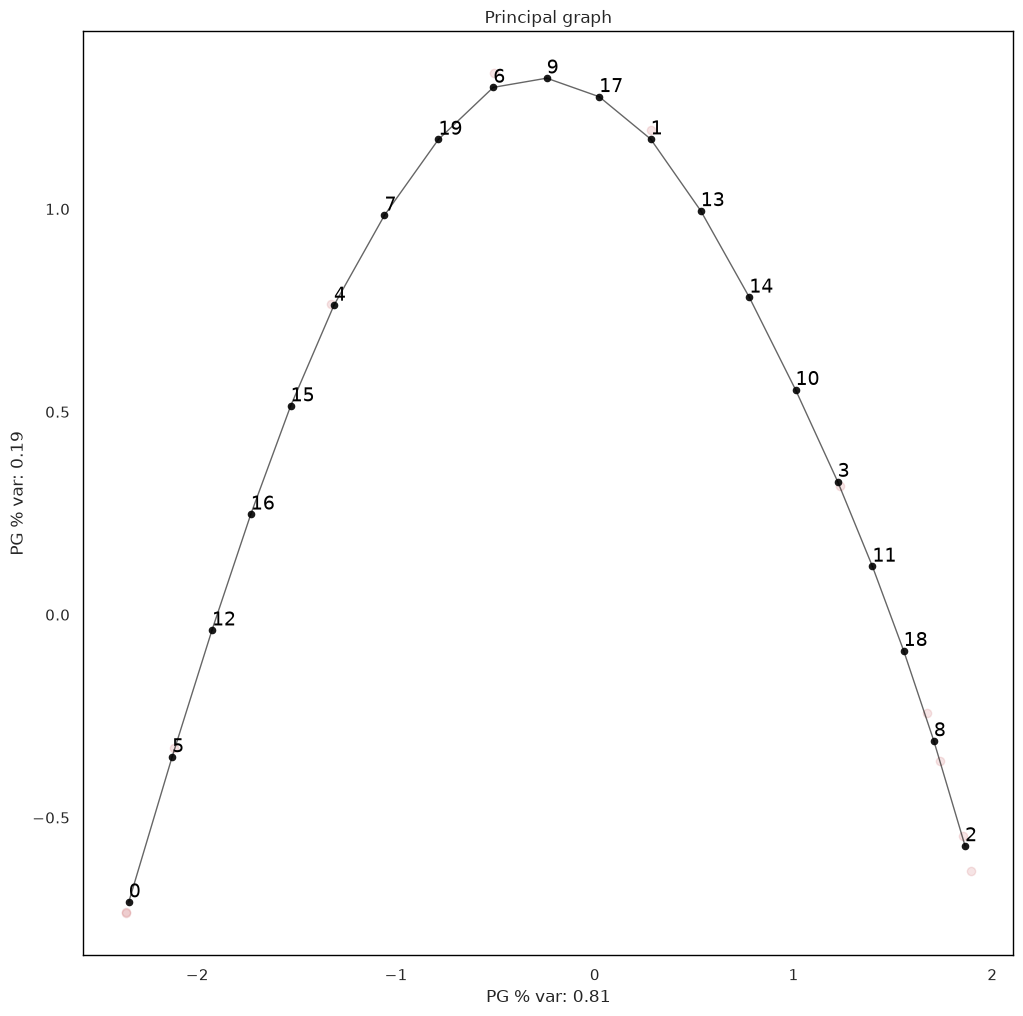

run27_Ctrl_3    0.000000
run28_Ctrl_2    0.000000
run28_Ctrl_5    0.443505
run27_Ctrl_1    1.792103
run28_ThPO_4    2.778859
run28_ThPO_3    3.581637
run29_ThPO_5    4.873844
run29_ThPO_4    5.581707
run27_MPL_2     5.716809
run28_MPL_1     5.935122
run29_MPL_2     5.961590
dtype: float64

In [35]:
pl.pl.fit_pricipla_graph(adata, source_node=0)

PT_inferred = pd.Series(
    adata.uns['pseudotime'],
    index=list(adata.uns['proportions'].keys())
).sort_values()
PT_inferred


### 9.5 Niche importance along the trajectory

``pl.tl.cell_importance`` fits a robust regression model to identify niches whose proportions change significantly along the pseudotime trajectory.


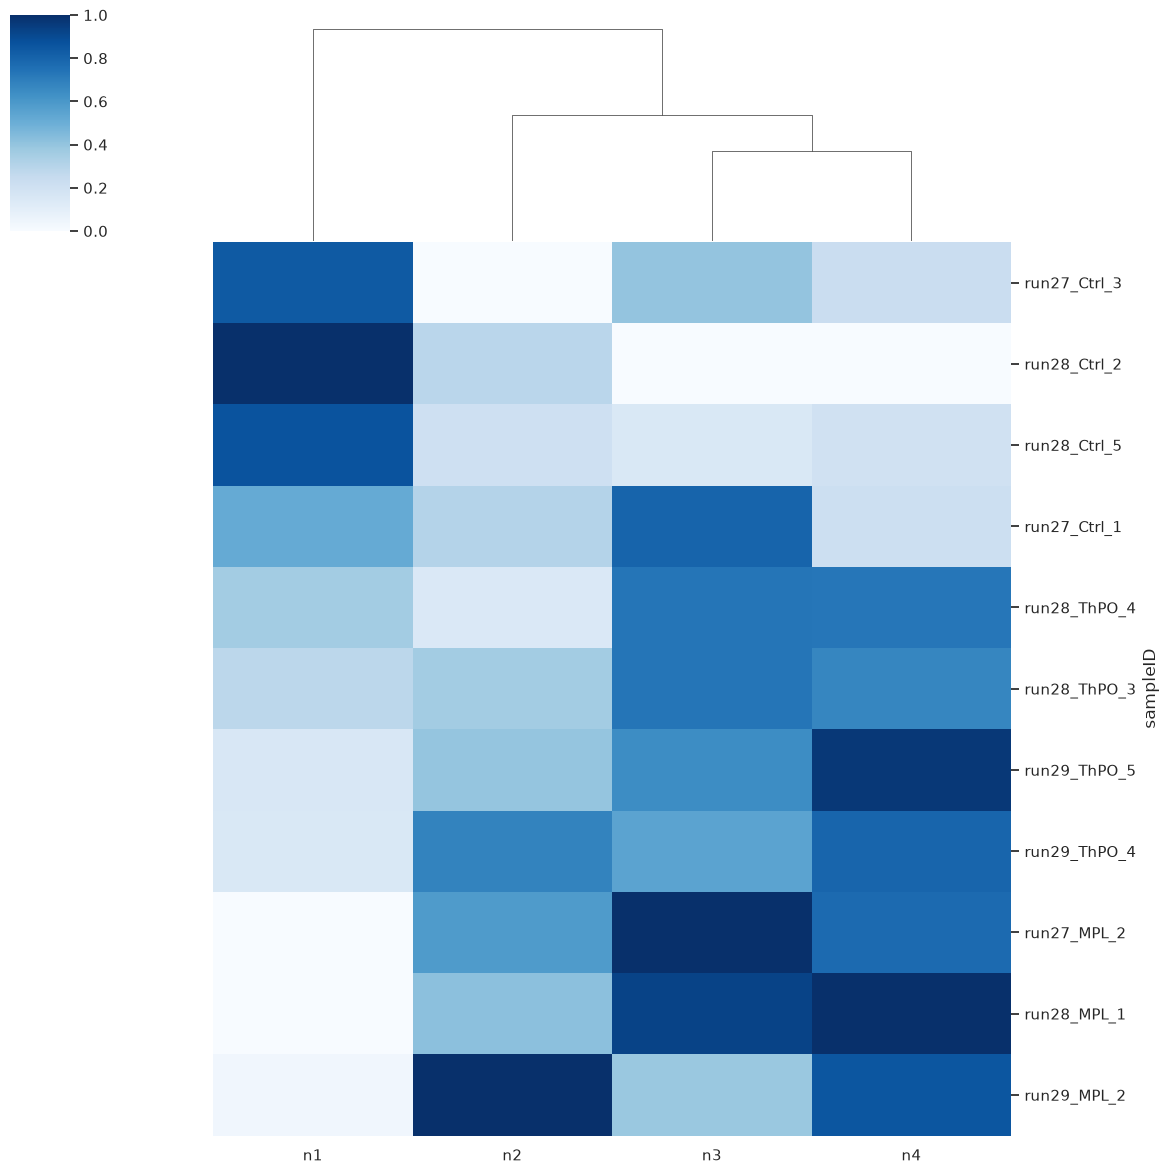

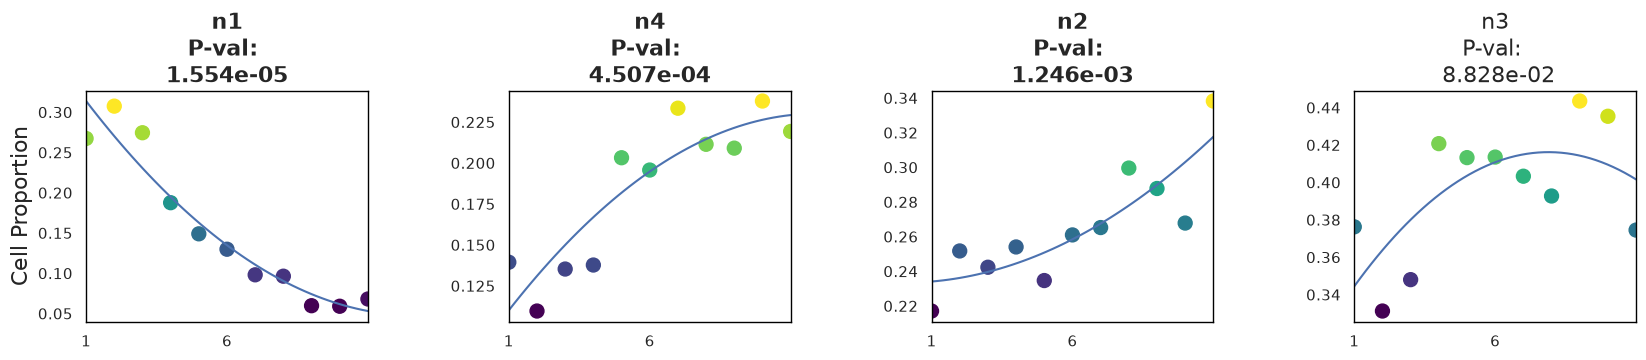

In [36]:
plt.rcParams.update({'font.size': 18})

pl.tl.cell_importance(
    adata,
    height=3,
    width=20,
    fontsize=16
)
#plt.savefig('./figures/PILOT_niche_importance_MPL_Ctrl.pdf', bbox_inches='tight')


### 9.6 Niche maps sorted by pseudotime

We visualise tissue slices with cells colored by niche and arrange them in a grid sorted by pseudotime to show how niche composition evolves along the trajectory.
We first save the individual niche maps.


In [37]:
os.makedirs('figures', exist_ok=True)
os.makedirs('results/PILOT', exist_ok=True)

col_list = clist.copy()
adata.uns['MPL_Ctrl_niche_colors'] = col_list

# Save per-slice images
for smpl in sampleTypesDF['sample']:
    sc.pl.spatial(
        adata=adata[adata.obs['sample'] == smpl].copy(),
        color='MPL_Ctrl_niche',
        img_key=None,
        library_id=None,
        spot_size=20,
        title='',
        frameon=False,
        legend_loc=None,
        save=f'_{smpl}_niches.png',
        show=False
    )


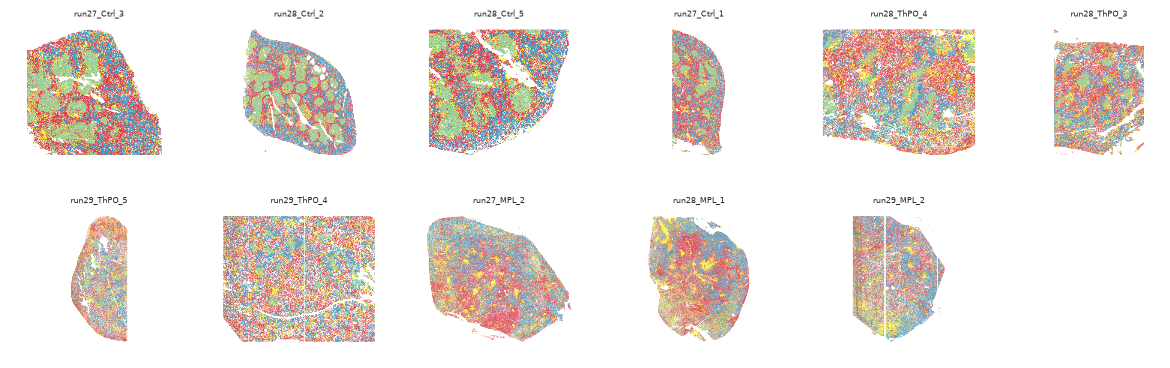

Saved grid to results/PILOT/slices_niches_by_pseudotime.pdf


In [38]:
# Workaround for missing imports in pilotpy
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pilotpy.plot.ploting as _pilot_plot
_pilot_plot.OffsetImage    = OffsetImage
_pilot_plot.AnnotationBbox = AnnotationBbox

# Arrange slices sorted by pseudotime
pl.pl.create_sample_grid(
    #df=pilot_adata.uns['orders'][::3],
    df=adata.uns['orders'],
    pattern='niches',
    image_dir='figures/',
    output_path='results/PILOT/slices_niches_by_pseudotime.pdf',
    zoom=0.27,
    num_rows=2
)


### 9.8 Co-localization pairs along the trajectory

We correlate each cell type pair co-localization probability with pseudotime using Spearman's rank correlation to identify which interactions are most strongly associated with disease progression.


In [39]:
# Spearman correlation of each co-localization pair with pseudotime
stats_spearman = [
    scipy.stats.spearmanr(colocPerSample[c][PT_inferred.index], PT_inferred)
    for c in colocPerSample.columns
]

coloc_stats = pd.DataFrame({
    'pairs':     colocPerSample.columns,
    'statistic': [s.statistic for s in stats_spearman],
    'p-value':   [s.pvalue    for s in stats_spearman]
}).set_index('pairs').sort_values('p-value')

coloc_stats.head(10)


,statistic,p-value
pairs,,
B_cell_zone-B_cell_zone,-0.988613,1.033126e-08
Red_pulp_RCs-Vessels,0.961278,2.448861e-06
Vessels-Red_pulp_RCs,0.961278,2.448861e-06
Central_artery-Red_pulp_RCs,0.956722,4.013026e-06
Red_pulp_RCs-Central_artery,0.956722,4.013026e-06
Red_pulp_RCs-Red_pulp_RCs,0.947611,9.356372e-06
Marginal_zone_region-Mesothelium,-0.924832,4.593718e-05
Marginal_zone_region-B_cell_zone,-0.924832,4.593718e-05
Mesothelium-Sinusoids,-0.924832,4.593718e-05


In [40]:
sig = coloc_stats[coloc_stats['p-value'] < 0.05]

pairs_pos = list(np.setdiff1d(sig[sig['statistic'] >  0.92].index, oneCTints))[:4]
pairs_neg = list(np.setdiff1d(sig[sig['statistic'] < -0.92].index, oneCTints))[:4]

print("Positively correlated with pseudotime:", pairs_pos)
print("Negatively correlated with pseudotime:", pairs_neg)


Positively correlated with pseudotime: ['Central_artery-Red_pulp_RCs', 'Macrophages-Sinusoids', 'Red_pulp_RCs-Central_artery', 'Red_pulp_RCs-Vessels']
Negatively correlated with pseudotime: ['B_cell_zone-Marginal_zone_region', 'B_cell_zone-T_cell_zone', 'Marginal_zone_region-B_cell_zone', 'Marginal_zone_region-Mesothelium']


In [41]:
coloc_sub = colocPerSample[pairs_pos + pairs_neg]
coloc_sub = coloc_sub.loc[PT_inferred.index]

# Store in AnnData for PILOT's feature_importance function
adata.uns['coloc_names']       = list(coloc_sub.columns)
adata.uns['proportions_coloc'] = dict(zip(coloc_sub.index, coloc_sub.values))


`pl.tl.feature_importance` applies the same robust regression model as `cell_importance`, but on the co-localization pairs stored in `adata.uns`:

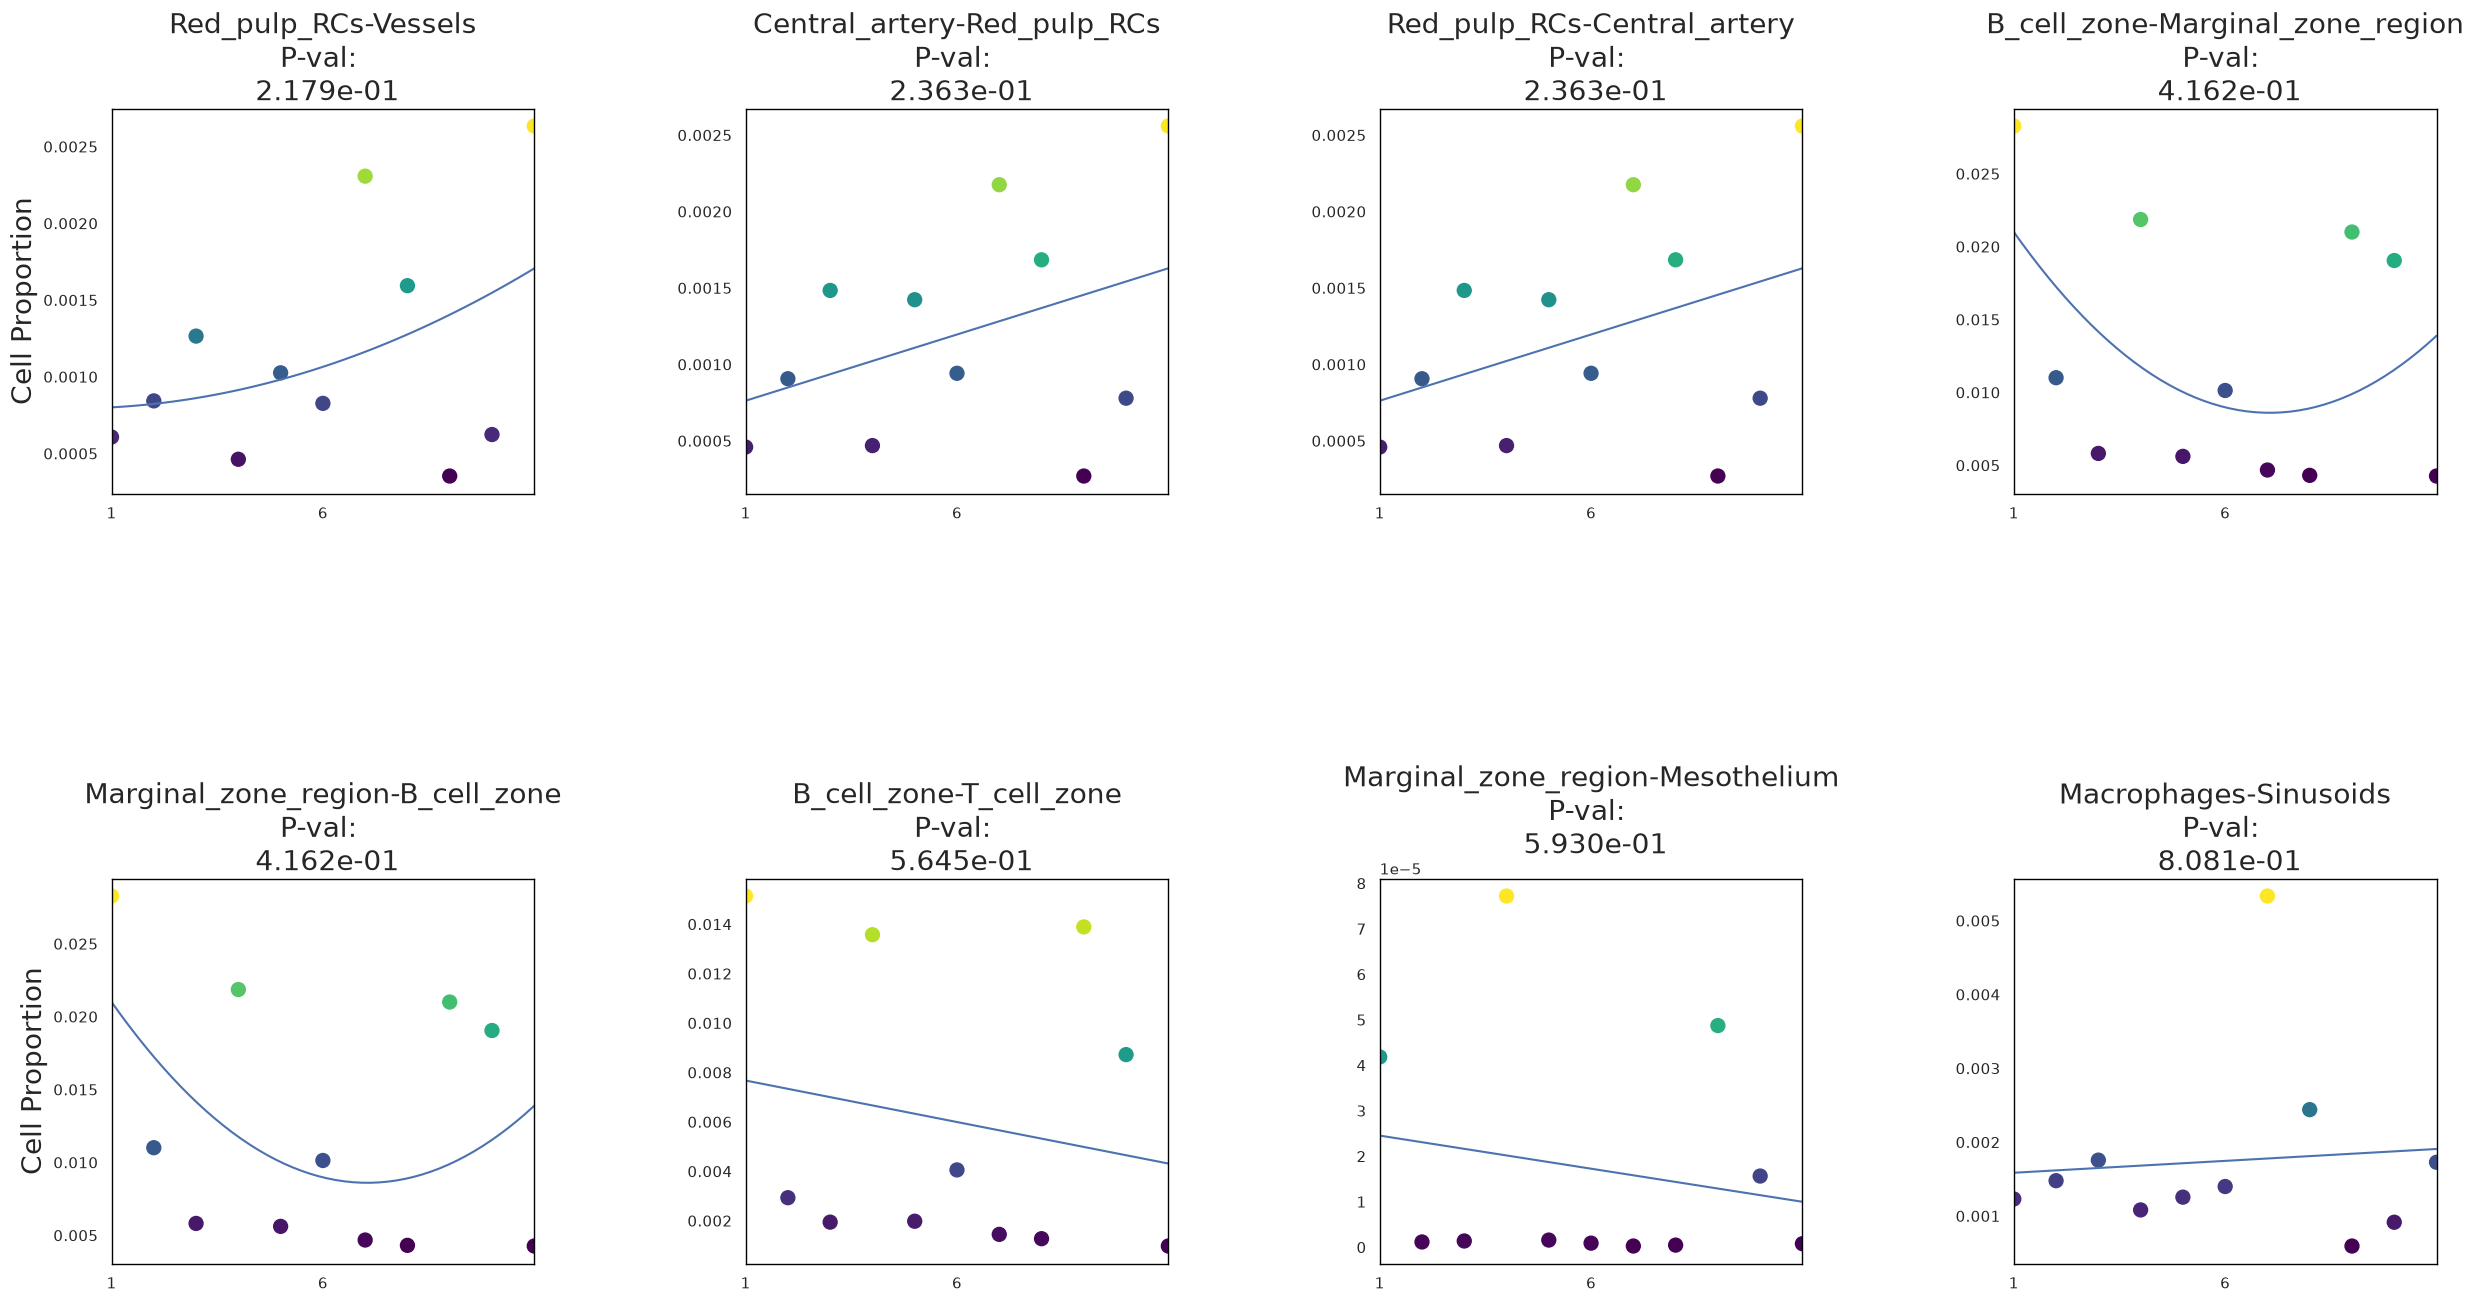

In [42]:
pl.tl.feature_importance(
    adata,
    feature_matrix='proportions_coloc',
    feature_names='coloc_names',
    height=15,
    width=30,
    fontsize=20,
    figsize=(6, 6)
)
plt.savefig('figures/coloc_pairs_trajectory_MPL_Ctrl.pdf', bbox_inches='tight')


---

## Summary

This tutorial demonstrated the full NicheSphere × PILOT workflow for CODEX multiplexed imaging data:

1. **Co-localization** — cell type pair co-localization probabilities were computed directly from CODEX spatial coordinates using a radius-based approach
2. **Differential co-localization** — Wilcoxon rank-sum tests identified pairs significantly enriched or depleted in MPL vs Ctrl
3. **Niche detection** — Louvain community detection on the differential co-localization network partitioned cell types into spatially coherent niches
4. **Niche mapping** — niches were mapped back onto individual cells and visualised across tissue slices and conditions
5. **PILOT trajectory** — optimal transport distances between niche compositions revealed a disease progression trajectory, with niche importance and co-localization pair correlations identifying the key drivers of MPL pathology

* For the **PIC-seq** version of this workflow see: [NicheSphere tutorial (PIC-seq)](Nichesphere_tutorial_BM_PICseq.ipynb)
* For the **Visium** version see: [Nichesphere_tutorial_MIvisium](Nichesphere_tutorial_MIvisium.ipynb)